### Defining utility

In [1]:
"""
Reliability diagrams, ECE and MCE for multiclass classifiers.

Supports:
  * Hard (canonical) labels: y_true is an int array of shape (N,)
  * Soft labels:              y_true is a float array of shape (N, K), rows sum to 1
  * Overall calibration:
        - "top_label" : confidence of argmax vs. correctness (Guo et al., 2017)
        - "classwise" : average of per-class one-vs-rest ECEs (Kull et al., 2019)
  * Per-class (one-vs-rest) reliability diagrams
  * Equal-width or equal-mass (quantile) binning — equal-mass is recommended
    for heavily imbalanced datasets where rare-class probabilities cluster in
    the low-confidence bins.

Robustness features for heavy class imbalance:
  * Equal-mass binning prevents most bins from being nearly empty for rare
    classes.
  * Per-bin sample counts are plotted alongside the reliability curve on a
    log scale so bins with unreliable estimates are visible.
  * Bins below `min_bin_count` are rendered faintly and excluded from MCE
    (they still contribute to ECE, weighted by their mass — which is small).
  * ECE / MCE are weighted by bin mass, not by a uniform average over bins.

References:
  Guo et al., "On Calibration of Modern Neural Networks", ICML 2017.
  Kull et al., "Beyond temperature scaling: ...", NeurIPS 2019.
  Nixon et al., "Measuring Calibration in Deep Learning", CVPR Workshops 2019.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Optional, Sequence, Union

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------------
# Data container
# ---------------------------------------------------------------------------


@dataclass
class BinStats:
    """Per-bin statistics for a reliability diagram.

    All arrays have length `n_bins`. Bins with zero count have NaN for
    `mean_confidence` and `mean_accuracy`.
    """

    bin_edges: np.ndarray  # shape (n_bins + 1,)
    counts: np.ndarray  # shape (n_bins,)  integer-ish
    mean_confidence: np.ndarray  # shape (n_bins,)  mean predicted prob in bin
    mean_accuracy: np.ndarray  # shape (n_bins,)  mean true prob / hit rate
    ece: float
    mce: float
    total: int
    # metadata
    binning: str  # "equal_width" or "equal_mass"
    min_bin_count: int  # bins below this were excluded from MCE

    @property
    def bin_centers(self) -> np.ndarray:
        return 0.5 * (self.bin_edges[:-1] + self.bin_edges[1:])

    @property
    def gap(self) -> np.ndarray:
        """Signed calibration gap per bin: accuracy - confidence.
        Positive means under-confident, negative means over-confident.
        """
        return self.mean_accuracy - self.mean_confidence


# ---------------------------------------------------------------------------
# Core computation
# ---------------------------------------------------------------------------


def _make_bin_edges(
    confidences: np.ndarray,
    n_bins: int,
    binning: str,
) -> np.ndarray:
    """Return bin edges of shape (n_bins + 1,)."""
    if binning == "equal_width":
        return np.linspace(0.0, 1.0, n_bins + 1)
    if binning == "equal_mass":
        # quantile-based edges. If there are ties or few unique values (common
        # for a heavily imbalanced rare class where most probs are near zero)
        # we fall back to unique quantile values to avoid zero-width bins.
        qs = np.linspace(0.0, 1.0, n_bins + 1)
        edges = np.quantile(confidences, qs)
        edges[0], edges[-1] = 0.0, 1.0
        # Deduplicate collapsed edges while preserving monotonicity.
        edges = np.maximum.accumulate(edges)
        # If too many duplicates, nudge them apart by a tiny epsilon so
        # digitize can still separate points. We keep the leftmost edge at 0
        # and the rightmost at 1.
        eps = 1e-12
        for i in range(1, len(edges)):
            if edges[i] <= edges[i - 1]:
                edges[i] = min(edges[i - 1] + eps, 1.0)
        return edges
    raise ValueError(f"Unknown binning '{binning}'. Use 'equal_width' or 'equal_mass'.")


def _bin_assign(confidences: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Map each confidence to a bin index in [0, n_bins - 1]."""
    n_bins = len(edges) - 1
    # np.digitize with right=True => (edges[i-1], edges[i]]
    # We want the leftmost bin to include 0.0, so we treat the first edge as
    # inclusive. Using right=True and then clipping handles this cleanly.
    idx = np.digitize(confidences, edges[1:-1], right=True)
    return np.clip(idx, 0, n_bins - 1)


def _compute_bin_stats(
    confidences: np.ndarray,
    targets: np.ndarray,
    n_bins: int,
    binning: str,
    min_bin_count: int,
) -> BinStats:
    """Compute bin stats for a 1-D stream of (confidence, target) pairs.

    `targets` may be 0/1 (hard) or in [0, 1] (soft). The math is identical:
    per-bin "accuracy" is the mean of `targets` in that bin.
    """
    confidences = np.asarray(confidences, dtype=np.float64).ravel()
    targets = np.asarray(targets, dtype=np.float64).ravel()
    if confidences.shape != targets.shape:
        raise ValueError(
            f"confidences and targets must have matching shape, got "
            f"{confidences.shape} vs {targets.shape}"
        )
    n = confidences.size
    if n == 0:
        raise ValueError("Empty input.")

    edges = _make_bin_edges(confidences, n_bins, binning)
    bin_idx = _bin_assign(confidences, edges)

    counts = np.bincount(bin_idx, minlength=n_bins).astype(np.int64)
    sum_conf = np.bincount(bin_idx, weights=confidences, minlength=n_bins)
    sum_target = np.bincount(bin_idx, weights=targets, minlength=n_bins)

    with np.errstate(invalid="ignore", divide="ignore"):
        mean_conf = np.where(counts > 0, sum_conf / np.maximum(counts, 1), np.nan)
        mean_acc = np.where(counts > 0, sum_target / np.maximum(counts, 1), np.nan)

    # ECE: mass-weighted average of |acc - conf|. Empty bins contribute 0.
    gap = np.abs(mean_acc - mean_conf)
    gap_safe = np.where(np.isnan(gap), 0.0, gap)
    weights = counts / n
    ece = float(np.sum(weights * gap_safe))

    # MCE: worst bin, ignoring bins below min_bin_count (unreliable estimates).
    reliable = counts >= min_bin_count
    if reliable.any():
        mce = float(np.nanmax(np.where(reliable, gap, -np.inf)))
        if mce == -np.inf:
            mce = float("nan")
    else:
        mce = float("nan")

    return BinStats(
        bin_edges=edges,
        counts=counts,
        mean_confidence=mean_conf,
        mean_accuracy=mean_acc,
        ece=ece,
        mce=mce,
        total=int(n),
        binning=binning,
        min_bin_count=min_bin_count,
    )


# ---------------------------------------------------------------------------
# Public API — hard labels
# ---------------------------------------------------------------------------


def compute_top_label_bins(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int = 15,
    binning: str = "equal_width",
    min_bin_count: int = 10,
) -> BinStats:
    """Top-label calibration: confidence of argmax vs. correctness.

    Parameters
    ----------
    probs : (N, K) array of predicted class probabilities.
    y_true : (N,) int array of true class labels  OR  (N, K) soft-label array.
             For soft labels, "correctness" becomes the true probability of
             the predicted class, p_true[i, argmax_i].
    """
    probs = np.asarray(probs, dtype=np.float64)
    if probs.ndim != 2:
        raise ValueError(f"probs must be 2-D (N, K), got shape {probs.shape}")
    pred = probs.argmax(axis=1)
    confidence = probs[np.arange(len(probs)), pred]

    y_true = np.asarray(y_true)
    if y_true.ndim == 1:
        target = (y_true == pred).astype(np.float64)
    elif y_true.ndim == 2:
        # soft label: true probability mass on the *predicted* class
        if y_true.shape != probs.shape:
            raise ValueError(
                f"soft y_true shape {y_true.shape} must match probs shape {probs.shape}"
            )
        target = y_true[np.arange(len(y_true)), pred].astype(np.float64)
    else:
        raise ValueError(f"y_true must be 1-D or 2-D, got shape {y_true.shape}")

    return _compute_bin_stats(confidence, target, n_bins, binning, min_bin_count)


def compute_classwise_bins(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int = 15,
    binning: str = "equal_width",
    min_bin_count: int = 10,
) -> list[BinStats]:
    """Per-class (one-vs-rest) bin stats — one BinStats per class.

    For class k:
      confidence = probs[:, k]
      target     = 1[y_true == k]   (hard)  or   y_true[:, k]  (soft)
    """
    probs = np.asarray(probs, dtype=np.float64)
    n, k_classes = probs.shape

    y_true = np.asarray(y_true)
    if y_true.ndim == 1:
        # Build one-hot lazily per class to save memory for many classes.
        def target_for(k: int) -> np.ndarray:
            return (y_true == k).astype(np.float64)

    elif y_true.ndim == 2:
        if y_true.shape != probs.shape:
            raise ValueError(
                f"soft y_true shape {y_true.shape} must match probs shape {probs.shape}"
            )

        def target_for(k: int) -> np.ndarray:
            return y_true[:, k].astype(np.float64)

    else:
        raise ValueError(f"y_true must be 1-D or 2-D, got shape {y_true.shape}")

    out: list[BinStats] = []
    for k in range(k_classes):
        out.append(
            _compute_bin_stats(
                probs[:, k], target_for(k), n_bins, binning, min_bin_count
            )
        )
    return out


def classwise_ece(bins_per_class: Sequence[BinStats]) -> float:
    """Macro-average of per-class ECEs (Kull et al., 2019).

    Unweighted across classes so rare classes are not drowned out. If you want
    a frequency-weighted version, weight by class prior externally.
    """
    return float(np.mean([b.ece for b in bins_per_class]))


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------


def plot_reliability_diagram(
    stats: BinStats,
    ax: Optional[plt.Axes] = None,
    ax_counts: Optional[plt.Axes] = None,
    title: str = "Reliability diagram",
    color: str = "tab:blue",
    show_gap_shading: bool = True,
) -> tuple[plt.Axes, Optional[plt.Axes]]:
    """Plot a single reliability diagram with an optional count histogram.

    If `ax_counts` is None, no count panel is drawn. For imbalanced data you
    should pass one — without it, readers cannot tell which bins are trustworthy.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    centers = stats.bin_centers
    widths = np.diff(stats.bin_edges)
    mass = stats.counts / max(stats.total, 1)
    reliable = stats.counts >= stats.min_bin_count

    # Perfect calibration reference
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        linewidth=1,
        label="perfect calibration",
    )

    # Gap shading: vertical bars from y=confidence to y=accuracy
    if show_gap_shading:
        for i in range(len(centers)):
            if stats.counts[i] == 0 or np.isnan(stats.mean_accuracy[i]):
                continue
            c = stats.mean_confidence[i]
            a = stats.mean_accuracy[i]
            alpha = 0.25 if reliable[i] else 0.08
            ax.bar(
                centers[i],
                height=a - c,
                bottom=c,
                width=widths[i] * 0.95,
                color="tab:red",
                alpha=alpha,
                edgecolor="none",
                zorder=1,
            )

    # Accuracy bars (what was actually observed in each bin)
    bar_alpha = np.where(reliable, 0.75, 0.25)
    for i in range(len(centers)):
        if stats.counts[i] == 0 or np.isnan(stats.mean_accuracy[i]):
            continue
        ax.bar(
            centers[i],
            height=stats.mean_accuracy[i],
            width=widths[i] * 0.95,
            color=color,
            alpha=bar_alpha[i],
            edgecolor="black",
            linewidth=0.5,
            zorder=2,
        )

    # Mark low-count bins explicitly
    for i in range(len(centers)):
        if 0 < stats.counts[i] < stats.min_bin_count:
            ax.plot(
                centers[i],
                stats.mean_accuracy[i],
                marker="x",
                color="black",
                markersize=8,
                zorder=4,
            )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ece_str = f"ECE={stats.ece:.3f}"
    mce_str = f"MCE={stats.mce:.3f}" if not np.isnan(stats.mce) else "MCE=n/a"
    ax.set_title(
        f"{title}\n{ece_str} | {mce_str} | N={stats.total:,}",
        fontsize=10,
    )
    ax.grid(True, alpha=0.3)

    # Counts panel — log scale makes heavy imbalance legible
    if ax_counts is not None:
        bar_colors = np.where(reliable, "tab:gray", "lightcoral")
        for i in range(len(centers)):
            ax_counts.bar(
                centers[i],
                height=max(stats.counts[i], 0.5),  # avoid log(0)
                width=widths[i] * 0.95,
                color=bar_colors[i],
                edgecolor="black",
                linewidth=0.3,
            )
        ax_counts.set_yscale("log")
        ax_counts.set_xlim(0, 1)
        ax_counts.set_ylabel("count")
        ax_counts.set_xlabel("Predicted probability")
        ax_counts.axhline(
            stats.min_bin_count,
            color="black",
            linestyle=":",
            linewidth=1,
            label=f"min count = {stats.min_bin_count}",
        )
        ax_counts.grid(True, alpha=0.3, which="both")
        ax_counts.legend(loc="upper right", fontsize=7)

    return ax, ax_counts


def plot_overall_reliability(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int = 15,
    binning: str = "equal_width",
    min_bin_count: int = 10,
    mode: str = "top_label",
    title: Optional[str] = None,
) -> tuple[Figure, BinStats]:
    """Convenience: compute + plot a single overall reliability diagram.

    mode : "top_label" (default) or "classwise"
      - top_label: one diagram, argmax confidence vs. correctness
      - classwise: one diagram built from stacking all (p_k, 1[y=k]) pairs.
        This is less common; classwise ECE is usually reported as the mean of
        per-class ECEs — use `compute_classwise_bins` + `classwise_ece` for that.
    """
    if mode == "top_label":
        stats = compute_top_label_bins(probs, y_true, n_bins, binning, min_bin_count)
        default_title = "Overall (top-label) reliability"
    elif mode == "classwise":
        probs = np.asarray(probs, dtype=np.float64)
        y_true = np.asarray(y_true)
        if y_true.ndim == 1:
            targets = np.zeros_like(probs)
            targets[np.arange(len(y_true)), y_true] = 1.0
        else:
            targets = y_true.astype(np.float64)
        stats = _compute_bin_stats(
            probs.ravel(), targets.ravel(), n_bins, binning, min_bin_count
        )
        default_title = "Overall (stacked classwise) reliability"
    else:
        raise ValueError(f"mode must be 'top_label' or 'classwise', got '{mode}'")

    fig = plt.figure(figsize=(6, 7.5), constrained_layout=True)
    gs = GridSpec(2, 1, height_ratios=[4, 1], figure=fig)
    ax_main = fig.add_subplot(gs[0, 0])
    ax_cnt = fig.add_subplot(gs[1, 0], sharex=ax_main)
    plot_reliability_diagram(
        stats,
        ax=ax_main,
        ax_counts=ax_cnt,
        title=title or default_title,
    )
    return fig, stats


def plot_per_class_reliability(
    probs: np.ndarray,
    y_true: np.ndarray,
    class_names: Optional[Sequence[str]] = None,
    classes: Optional[Sequence[int]] = None,
    n_bins: int = 15,
    binning: str = "equal_width",
    min_bin_count: int = 10,
    ncols: int = 4,
    figsize_per_panel: tuple[float, float] = (3.4, 4.2),
    suptitle: Optional[str] = None,
) -> tuple[Figure, list[BinStats]]:
    """Grid of one-vs-rest reliability diagrams, one per class.

    `classes` : subset of class indices to plot (useful for 40-class problems
                where you only want to inspect a few). If None, plots all.
    """
    all_stats = compute_classwise_bins(probs, y_true, n_bins, binning, min_bin_count)
    K = len(all_stats)

    if classes is None:
        classes = list(range(K))
    if class_names is None:
        class_names = [f"class {k}" for k in range(K)]

    n = len(classes)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
    )
    # Two rows per class (reliability + counts) arranged in a ncols grid.
    gs = GridSpec(nrows * 2, ncols, figure=fig, height_ratios=[4, 1] * nrows)

    for plot_idx, k in enumerate(classes):
        row = plot_idx // ncols
        col = plot_idx % ncols
        ax_main = fig.add_subplot(gs[row * 2, col])
        ax_cnt = fig.add_subplot(gs[row * 2 + 1, col], sharex=ax_main)
        plot_reliability_diagram(
            all_stats[k],
            ax=ax_main,
            ax_counts=ax_cnt,
            title=str(class_names[k]),
        )

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=14)

    return fig, all_stats


# ---------------------------------------------------------------------------
# Summary helpers
# ---------------------------------------------------------------------------


def summary_table(
    bins_per_class: Sequence[BinStats],
    class_names: Optional[Sequence[str]] = None,
    class_priors: Optional[np.ndarray] = None,
) -> str:
    """Return a simple text table of per-class ECE / MCE / N."""
    if class_names is None:
        class_names = [f"class {k}" for k in range(len(bins_per_class))]
    header = f"{'class':<20}{'N':>10}{'prior':>10}{'ECE':>10}{'MCE':>10}"
    lines = [header, "-" * len(header)]
    for i, b in enumerate(bins_per_class):
        prior = class_priors[i] if class_priors is not None else np.nan
        mce = "n/a" if np.isnan(b.mce) else f"{b.mce:.4f}"
        prior_str = "n/a" if np.isnan(prior) else f"{prior:.4f}"
        lines.append(
            f"{str(class_names[i]):<20}{b.total:>10,}{prior_str:>10}"
            f"{b.ece:>10.4f}{mce:>10}"
        )
    macro = np.mean([b.ece for b in bins_per_class])
    lines.append("-" * len(header))
    lines.append(f"{'classwise ECE (macro)':<20}{'':>10}{'':>10}{macro:>10.4f}")
    return "\n".join(lines)

### Visualizing diagrams

In [ ]:
# hard_labels_results_path = "/data/dmytro/Experiments/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_hard_labels_minibatch_balanced/pseudobulk/test_predicted.pkl"
# soft_labels_ours_results_path = "/data/dmytro/Experiments/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/test_predicted.pkl"
# soft_labels_without_pooling = "/data/dmytro/Experiments/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_no_data_leak_postfiltered_min_length_50_soft_labels_NO_POOLING_jakkard/pseudobulk/test_predicted.pkl"
# soft_labels_without_pooling_dismir = "/data/dmytro/Experiments/pseudobulk/Dismir_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_NO_POOLING/pseudobulk/test_predicted.pkl"
# soft_labels_with_pooling_dismir = "/data/dmytro/Experiments/pseudobulk/Dismir_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/test_predicted.pkl"
# hard_labels_results_path_dismir = "/data/dmytro/Experiments/pseudobulk/Dismir_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_hard_labels/pseudobulk/test_predicted.pkl"

In [36]:
pseudobulk_soft_labels_canonical_methylbert = "/mnt/data/syto_experiments/mlflow/198121009408531961/5f67c6d66bac4253b3adc92f61ebd2cd/artifacts/test_predicted.pkl"
pseudobulk_soft_without_pooling_methylbert = "/mnt/data/syto_experiments/mlflow/198121009408531961/7517527ef86842d7b5060b3d473984a2/artifacts/test_predicted.pkl"
rrbs_soft_labels_canonical_methylbert = "/mnt/data/syto_experiments/mlflow/437308559251151883/cc82a581b0154c14824fd19896b81216/artifacts/valid_predicted.pkl"
rrbs_soft_without_pooling_methylbert = "/mnt/data/syto_experiments/mlflow/437308559251151883/a48a9ef342bf426eaa81a18e9b9ead26/artifacts/valid_predicted.pkl"
pseudobulk_soft_with_pooling_methylbert = "/mnt/data/syto_experiments/mlflow/198121009408531961/e21d054a7dc04dd2a7e8de4231efaa56/artifacts/test_predicted.pkl"

In [3]:
from collections import defaultdict
import pickle

In [4]:
# data = defaultdict()
# for p, name in zip(
#     [
#         hard_labels_results_path,
#         soft_labels_ours_results_path,
#         soft_labels_without_pooling,
#         soft_labels_without_pooling_dismir,
#         soft_labels_with_pooling_dismir,
#         hard_labels_results_path_dismir,
#     ],
#     [
#         "Hard Labels MethylBERT",
#         "Soft Labels Ours MethylBERT",
#         "Soft Labels W/P MethylBERT",
#         "Soft Labels W/P Dismir",
#         "Soft Labels Ours Dismir",
#         "Hard Labels Dismir",
#     ],
# ):
#     with open(p, "rb") as f:
#         data[name] = pickle.load(f)

In [37]:
data = defaultdict()
for p, name in zip(
    [   pseudobulk_soft_without_pooling_methylbert,
        pseudobulk_soft_labels_canonical_methylbert,
        rrbs_soft_without_pooling_methylbert,
        rrbs_soft_labels_canonical_methylbert,
        pseudobulk_soft_with_pooling_methylbert,
    ],
    [
        "PB Soft Labels W/P MethylBERT",
        "PB Soft Labels Canonical MethylBERT",
        "OOD Soft Labels W/P MethylBERT",
        "OOD Soft Labels Canonical MethylBERT",
        "PB Soft Labels MethylBERT"
    ],
):
    with open(p, "rb") as f:
        data[name] = pickle.load(f)

In [41]:
predictions = defaultdict()
for key, value in data.items():

    if "Canonical" in key:
        N = 40
        label_col = "label"
    else:
        N = 39
        label_col = "soft_label"
    # preds = data[key][[f"prediction_{i}" for i in range(N)]].to_numpy()
    data_filtered = data[key][data[key]["dmr_ctype_label"]==data[key]["original_label"]]
    preds_ontarget = [row[f"prediction_{row["dmr_ctype_label"]}"] for _,row in data_filtered.iterrows()]
    
    # labels = data[key][label_col].to_numpy()
    # labels = np.array([x for x in labels])
    predictions[key] = preds_ontarget


In [ ]:
data_filtered = data[data["dmr_ctype_label"]==data["original_label"]]
preds_ontarget = [row[f"prediction_{row["dmr_ctype_label"]}"] for _,row in data_filtered.iterrows()]

<Axes: ylabel='Density'>

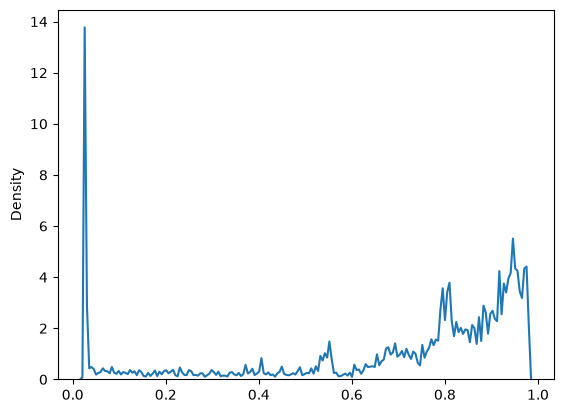

In [44]:
import seaborn as sns
sns.kdeplot(data=np.array(predictions["PB Soft Labels MethylBERT"]),bw_adjust=0.01)

<Axes: ylabel='Density'>

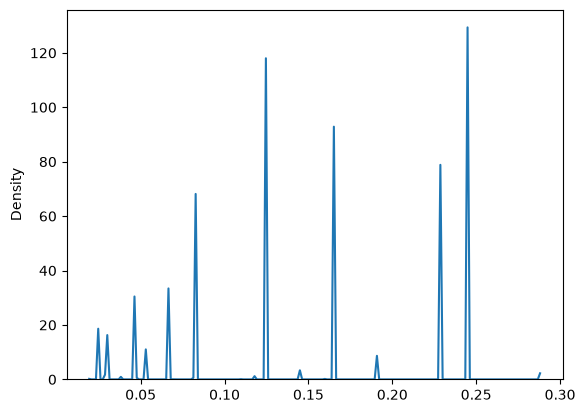

In [47]:
import seaborn as sns
sns.kdeplot(data=np.array(predictions["PB Soft Labels W/P MethylBERT"]),bw_adjust=0.01)

In [ ]:
import seaborn as sns
sns.kdeplot(data=np.array(predictions["OOD Soft Labels W/P MethylBERT"]),bw_adjust=0.01)

<Axes: ylabel='Density'>

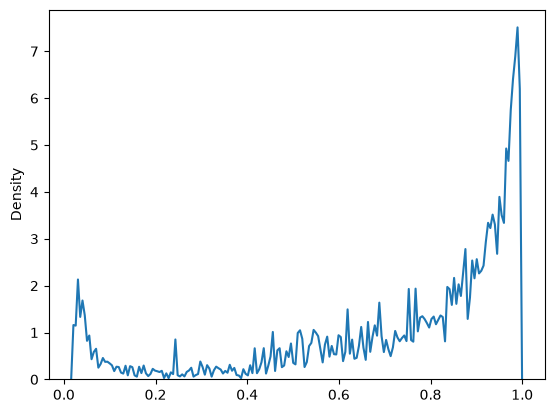

In [48]:
import seaborn as sns
sns.kdeplot(data=np.array(predictions["OOD Soft Labels W/P MethylBERT"]),bw_adjust=0.01)

In [49]:
preds_hard = data["Hard Labels MethylBERT"][
    [f"prediction_{i}" for i in range(40)]
].to_numpy()
labels_hard = data["Hard Labels MethylBERT"]["label"].to_numpy()
labels_hard = np.array([x for x in labels_hard])

preds_soft = data["Soft Labels Ours MethylBERT"][
    [f"prediction_{i}" for i in range(39)]
].to_numpy()
labels_soft = data["Soft Labels Ours MethylBERT"]["soft_label"].to_numpy()
labels_soft = np.array([x for x in labels_soft])

preds_soft_wp = data["Soft Labels W/P MethylBERT"][
    [f"prediction_{i}" for i in range(39)]
].to_numpy()
labels_soft_wp = data["Soft Labels W/P MethylBERT"]["soft_label"].to_numpy()
labels_soft_wp = np.array([x for x in labels_soft_wp])

preds_soft_wp_dismir = data["Soft Labels W/P Dismir"][
    [f"prediction_{i}" for i in range(39)]
].to_numpy()
labels_soft_wp_dismir = data["Soft Labels W/P Dismir"]["soft_label"].to_numpy()
labels_soft_wp_dismir = np.array([x for x in labels_soft_wp_dismir])

preds_soft_dismir = data["Soft Labels Ours Dismir"][
    [f"prediction_{i}" for i in range(39)]
].to_numpy()
labels_soft_dismir = data["Soft Labels Ours Dismir"]["soft_label"].to_numpy()
labels_soft_dismir = np.array([x for x in labels_soft_dismir])


preds_hard_dismir = data["Hard Labels Dismir"][
    [f"prediction_{i}" for i in range(40)]
].to_numpy()
labels_hard_dismir = data["Hard Labels Dismir"]["label"].to_numpy()
labels_hard_dismir = np.array([x for x in labels_hard_dismir])

(<Figure size 600x750 with 2 Axes>,
 BinStats(bin_edges=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]), counts=array([35011397,    46476,    21442,     5620,     3251,     2441,
            2194,     1892,     1657,     1484,     1402,     1234,
            1107,     1017,      864,      846,      769,      834,
             695,      584,      593,      690,

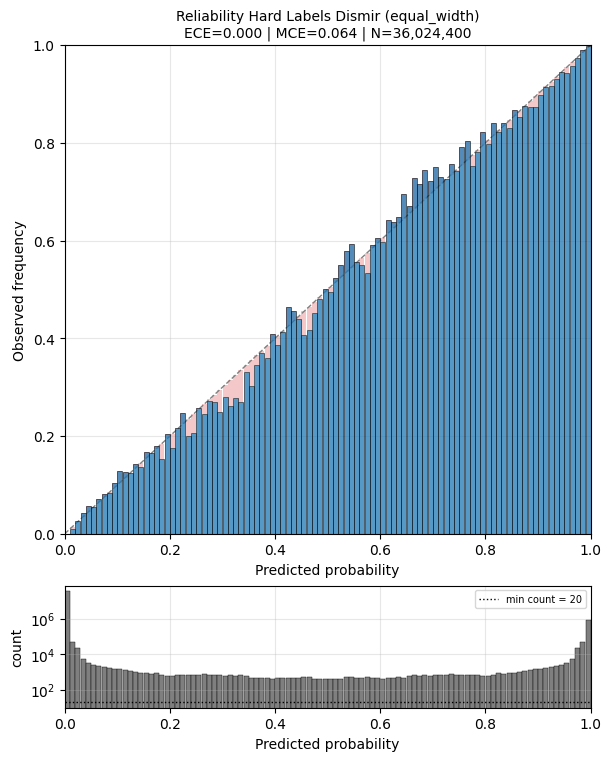

In [50]:
binning = "equal_width"
plot_overall_reliability(
    preds_hard_dismir,
    labels_hard_dismir,
    n_bins=100,
    binning=binning,
    min_bin_count=20,
    mode="classwise",
    title=f"Reliability Hard Labels Dismir ({binning})",
)

In [55]:
labels_hard_dismir[0]

np.int64(39)

In [ ]:
# labels_hard_onehot = []
# for i in labels_hard_dismir:
#     if i == 39:
#         item = np.array([1/39]*39)
#     else:
#         item = np.zeros(39)
#         item[i] =1
#     labels_hard_onehot.append(item)
# labels_hard_onehot = np.array(labels_hard_onehot)

(<Figure size 600x750 with 2 Axes>,
 BinStats(bin_edges=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]), counts=array([ 1028231,  1088059, 32075958,   779212,    54936,    22820,
           13020,     8902,     5511,     3619,     2613,     1807,
            1092,      782,      760,      617,      483,      504,
             527,      359,      390,      270,

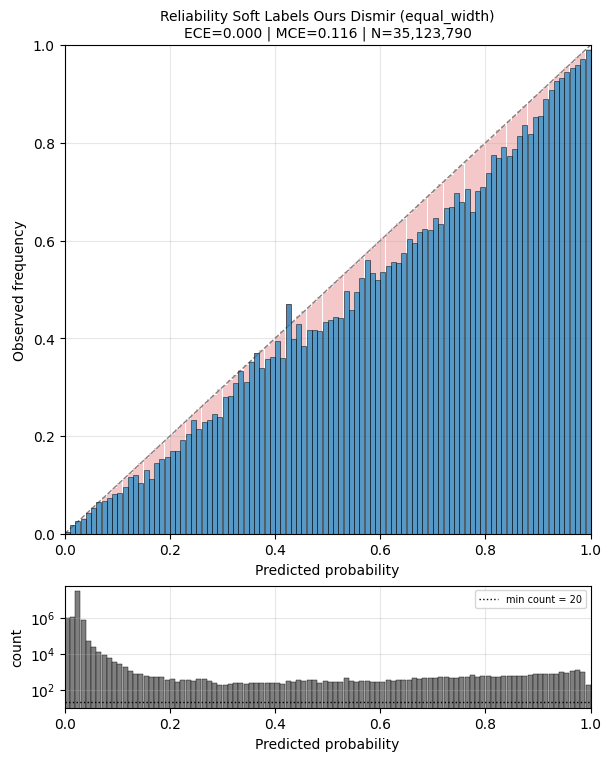

In [61]:
binning = "equal_width"
plot_overall_reliability(
    preds_soft_dismir,
    labels_soft_dismir,
    n_bins=100,
    binning=binning,
    min_bin_count=20,
    mode="classwise",
    title=f"Reliability Soft Labels Ours Dismir ({binning})",
)

(<Figure size 600x750 with 2 Axes>,
 BinStats(bin_edges=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]), counts=array([ 1263307,  2005454, 28759206,  2550464,   252057,   107340,
           58216,    35452,    20766,    12455,     8004,     5307,
            3803,     2695,     1935,     1531,     1112,      896,
             814,      767,      693,      616,

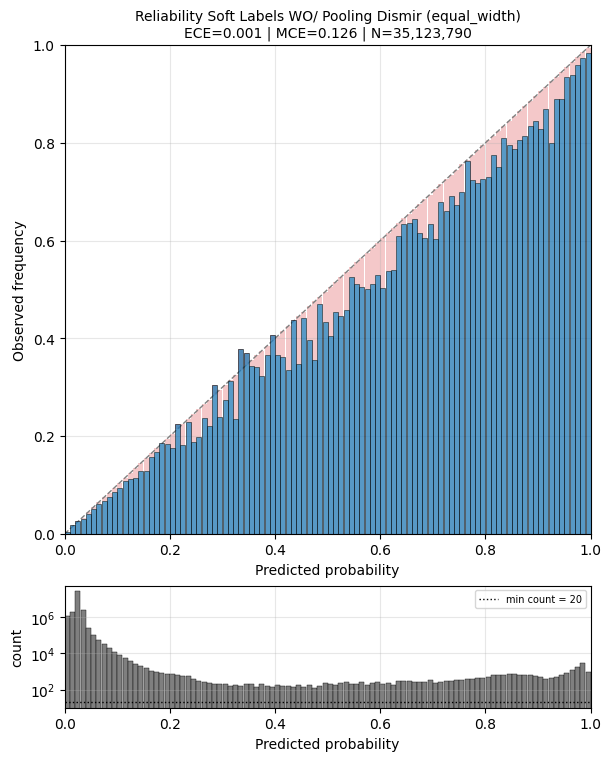

In [9]:
binning = "equal_width"
plot_overall_reliability(
    preds_soft_wp_dismir,
    labels_soft_wp_dismir,
    n_bins=100,
    binning=binning,
    min_bin_count=20,
    mode="classwise",
    title=f"Reliability Soft Labels WO/ Pooling Dismir ({binning})",
)

(<Figure size 600x750 with 2 Axes>,
 BinStats(bin_edges=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]), counts=array([34766273,   129241,    58283,    26924,    12791,     8257,
            6815,     6120,     7564,     5375,     5905,     4662,
            3506,     2763,     3154,     2266,     3703,     3832,
            3510,     3556,     3973,     4868,

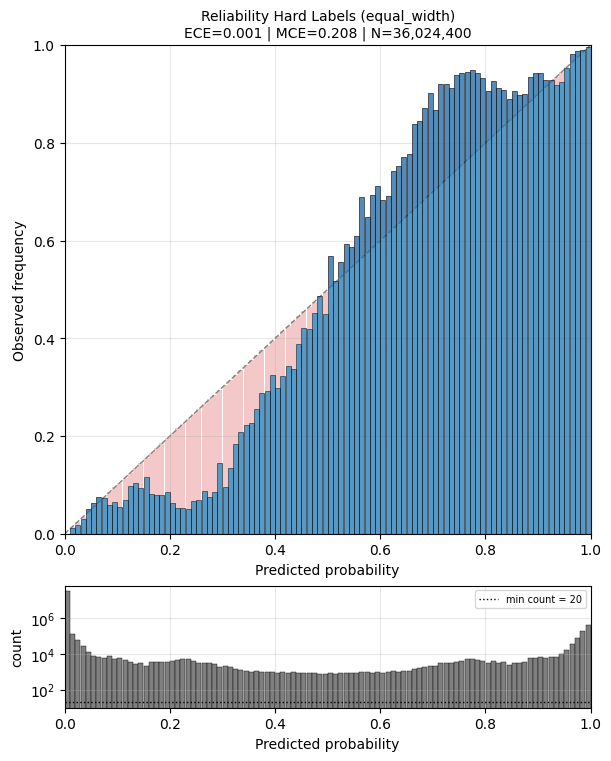

In [85]:
binning = "equal_width"
plot_overall_reliability(
    preds_hard,
    labels_hard,
    n_bins=100,
    binning=binning,
    min_bin_count=20,
    mode="classwise",
    title=f"Reliability Hard Labels ({binning})",
)

(<Figure size 600x750 with 2 Axes>,
 BinStats(bin_edges=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]), counts=array([ 1113485,   448722, 33217132,   199424,    43349,    19723,
           14326,     7478,     6224,     3757,     2873,     2119,
            1391,     1142,      918,      844,      960,      861,
             824,      700,      668,      515,

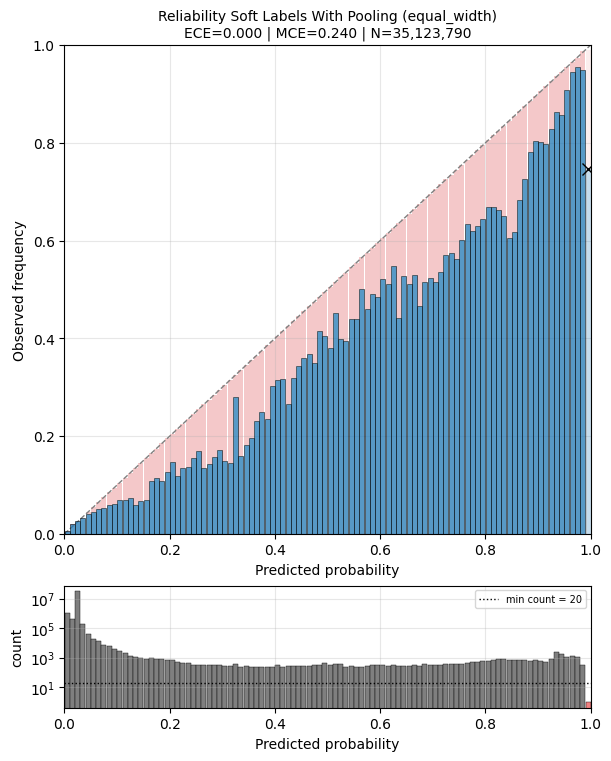

In [84]:
binning = "equal_width"
plot_overall_reliability(
    preds_soft,
    labels_soft,
    n_bins=100,
    binning=binning,
    min_bin_count=20,
    mode="classwise",
    title=f"Reliability Soft Labels With Pooling ({binning})",
)

In [67]:
from syto.data.soft_labeling import (
    extract_cpg_signature,
    signature_distance,
    apply_normalized_knn_smoothing,
)

In [69]:
data["Soft Labels W/P"]["cpg_sig"] = data["Soft Labels W/P"].apply(
    extract_cpg_signature, axis=1
)

(<Figure size 600x750 with 2 Axes>,
 BinStats(bin_edges=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]), counts=array([  151708, 13080791, 15322335,  4150064,  1491444,   216875,
          114581,    78498,    41812,        0,   167196,    44187,
           32210,    20895,        0,        0,    16629,        0,
           44824,        0,    15413,        0,

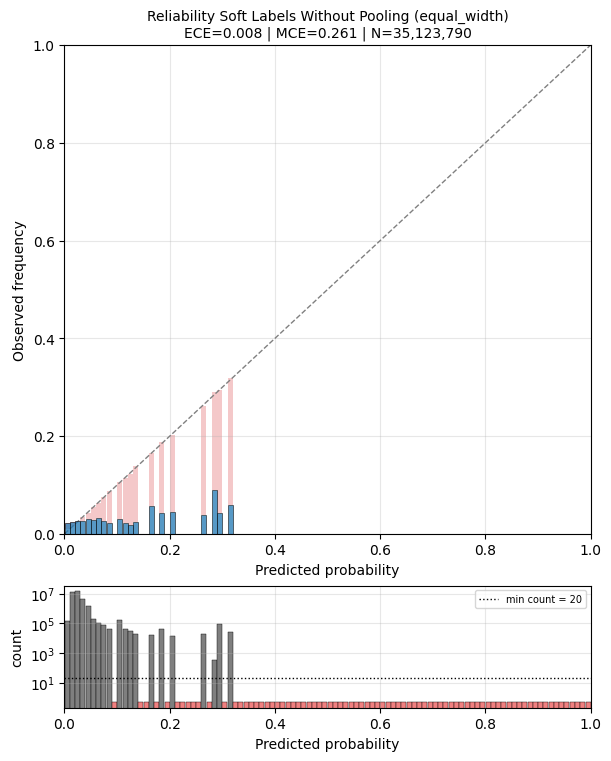

In [86]:
binning = "equal_width"
plot_overall_reliability(
    preds_soft_wp,
    labels_soft_wp,
    n_bins=100,
    binning=binning,
    min_bin_count=20,
    mode="classwise",
    title=f"Reliability Soft Labels Without Pooling ({binning})",
)

In [18]:
classes_to_show = [x for x in range(39)]

class_names = [f"class {k}" + (" (bg)" if k == 39 else "") for k in range(39)]

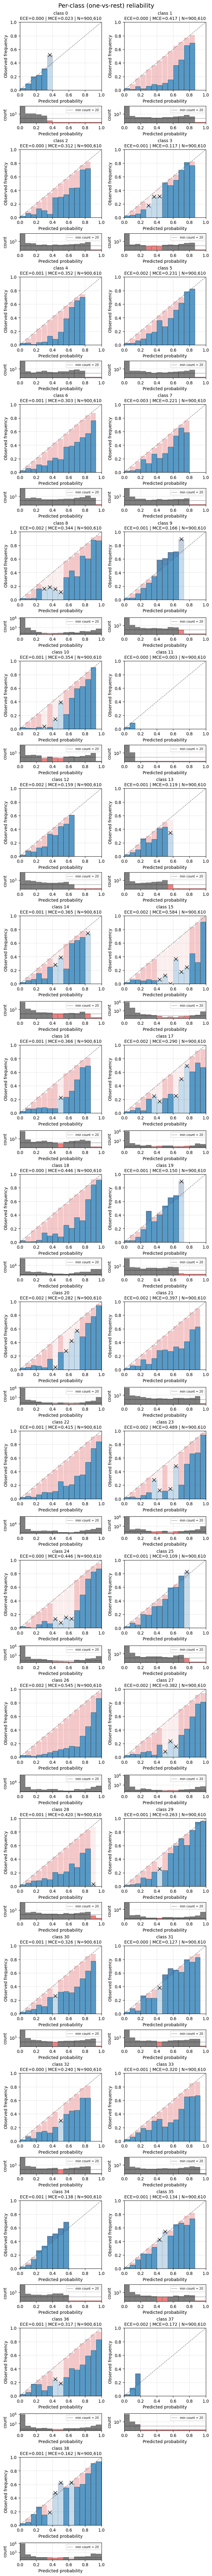

In [94]:
fig, all_stats = plot_per_class_reliability(
    preds_soft,
    labels_soft,
    class_names=class_names,
    classes=classes_to_show,
    n_bins=15,
    binning="equal_width",
    min_bin_count=20,
    ncols=2,
    suptitle="Per-class (one-vs-rest) reliability",
)

In [26]:
classes_to_show = [x for x in range(40)]

class_names = [f"class {k}" + (" (bg)" if k == 39 else "") for k in range(40)]

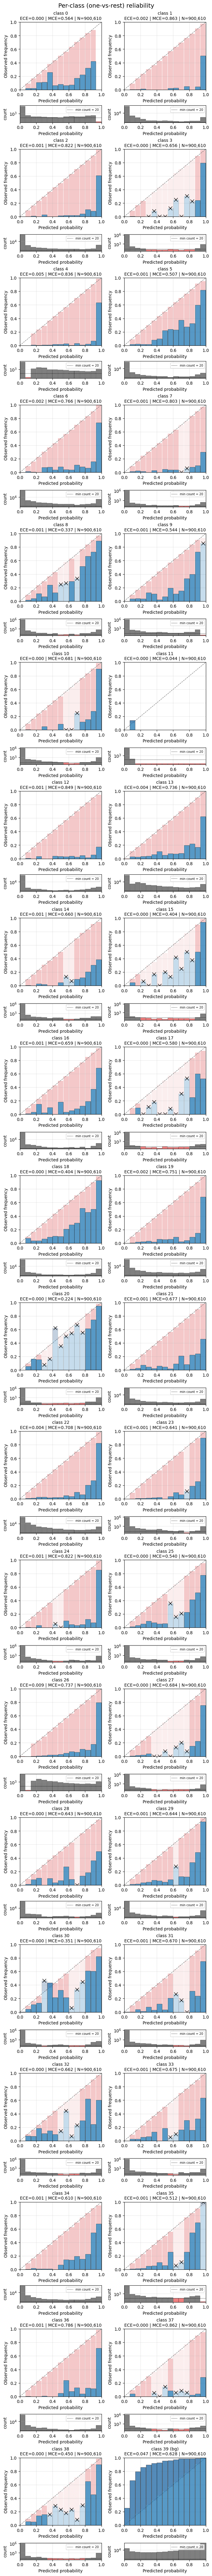

In [96]:
fig, all_stats = plot_per_class_reliability(
    preds_hard,
    labels_hard,
    class_names=class_names,
    classes=classes_to_show,
    n_bins=15,
    binning="equal_width",
    min_bin_count=20,
    ncols=2,
    suptitle="Per-class (one-vs-rest) reliability",
)

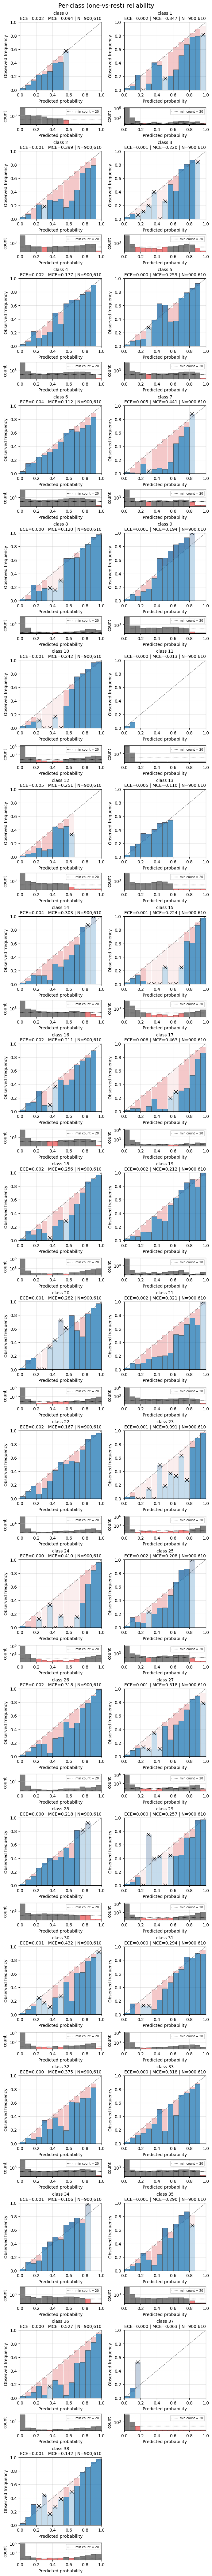

In [19]:
fig, all_stats = plot_per_class_reliability(
    preds_soft_dismir,
    labels_soft_dismir,
    class_names=class_names,
    classes=classes_to_show,
    n_bins=15,
    binning="equal_width",
    min_bin_count=20,
    ncols=2,
    suptitle="Per-class (one-vs-rest) reliability",
)

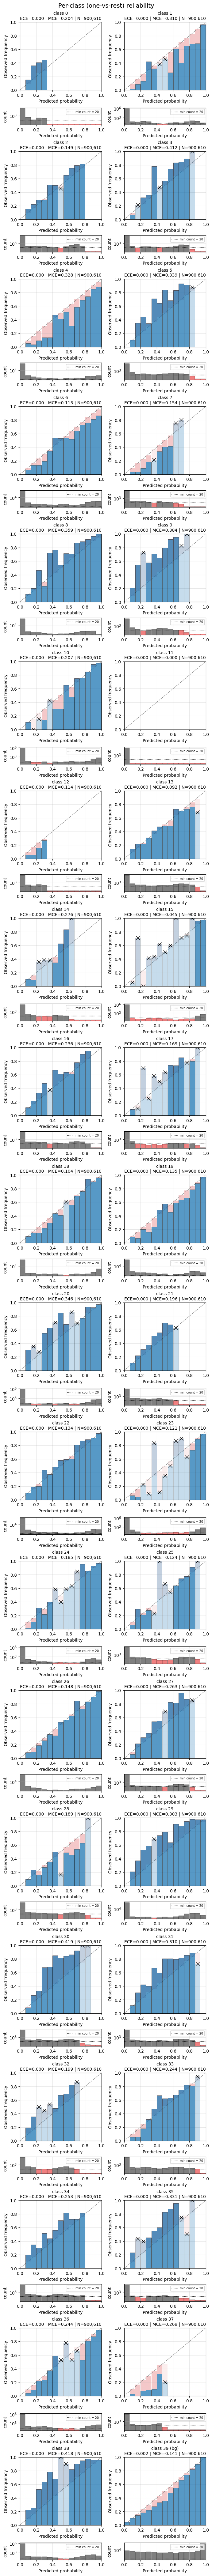

In [51]:
fig, all_stats = plot_per_class_reliability(
    preds_hard_dismir,
    labels_hard_dismir,
    class_names=class_names,
    classes=classes_to_show,
    n_bins=15,
    binning="equal_width",
    min_bin_count=20,
    ncols=2,
    suptitle="Per-class (one-vs-rest) reliability",
)